In [ ]:
import pandas as pd
import requests
import time
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix


In [338]:
# file paths
input_file = "../steam_1000.jsonl"
output_file = "steam_with_owners.jsonl"
FILE_PATH = "steam_with_owners.jsonl"

In [339]:
'''
# fetch owner data of specific appid from SteamSpy

def get_owners(appid):
    #fetch owner data of specific appid from SteamSpy

    url = f"https://steamspy.com/api.php?request=appdetails&appid={appid}"
    
    try:
        response = requests.get(url, timeout=10)
        data = response.json()

        # if there is no result, return "0 .. 0"
        return data.get("owners", "0 .. 0")
    except Exception:
        return None

#iter over input file, fetch owners data, and write to output file
with open(input_file, "r", encoding="utf-8") as f_in, \
     open(output_file, "w", encoding="utf-8") as f_out:
    
    for i, line in enumerate(f_in, start=1):
        game = json.loads(line)

        # only fetch if "owners_range" is missing or "0 .. 0"
        if "owners_range" not in game or game["owners_range"] == "0 .. 0":

            # get appid and fetch owners data
            appid = game.get("steam_appid")
            owners = get_owners(appid)

            if owners:
                game["owners_range"] = owners
                time.sleep(1.0) 
        
        # write game data to output file
        f_out.write(json.dumps(game, ensure_ascii=False) + "\n")

        if i % 50 == 0:
            print(i, "line processed")
        
'''

'\n# fetch owner data of specific appid from SteamSpy\n\ndef get_owners(appid):\n    #fetch owner data of specific appid from SteamSpy\n\n    url = f"https://steamspy.com/api.php?request=appdetails&appid={appid}"\n    \n    try:\n        response = requests.get(url, timeout=10)\n        data = response.json()\n\n        # if there is no result, return "0 .. 0"\n        return data.get("owners", "0 .. 0")\n    except Exception:\n        return None\n\n#iter over input file, fetch owners data, and write to output file\nwith open(input_file, "r", encoding="utf-8") as f_in,      open(output_file, "w", encoding="utf-8") as f_out:\n    \n    for i, line in enumerate(f_in, start=1):\n        game = json.loads(line)\n\n        # only fetch if "owners_range" is missing or "0 .. 0"\n        if "owners_range" not in game or game["owners_range"] == "0 .. 0":\n\n            # get appid and fetch owners data\n            appid = game.get("steam_appid")\n            owners = get_owners(appid)\n\n    

In [340]:
# analyze the distribution of owner ranges

range_counter = Counter()

with open(output_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)

            # if "owners_range" is missing, count it as "Unknown"
            owner_range = data.get("owners_range", "Unknown")
            range_counter[owner_range] += 1
            
def get_lower_bound(range_str):
    '''extract the lower bound of the owner range for sorting'''
    if range_str == "Unknown":
        return -1 
    return int(range_str.split(' .. ')[0].replace(',', ''))

# sort the owner ranges by their lower bound
sorted_items = sorted(range_counter.items(), key=lambda item: get_lower_bound(item[0]))

# print the sorted distribution
sorted_keys = [item[0] for item in sorted_items]
sorted_values = [item[1] for item in sorted_items]

print("Owner Range Distribution (Sorted by Size):")
for k, v in sorted_items:
    print(f"{k}: {v} games")

print(f"Total games: {sum(sorted_values)}")


Owner Range Distribution (Sorted by Size):
0 .. 20,000: 262 games
20,000 .. 50,000: 24 games
50,000 .. 100,000: 39 games
100,000 .. 200,000: 73 games
200,000 .. 500,000: 111 games
500,000 .. 1,000,000: 110 games
1,000,000 .. 2,000,000: 154 games
2,000,000 .. 5,000,000: 126 games
5,000,000 .. 10,000,000: 48 games
10,000,000 .. 20,000,000: 26 games
20,000,000 .. 50,000,000: 21 games
50,000,000 .. 100,000,000: 4 games
100,000,000 .. 200,000,000: 2 games
Total games: 1000


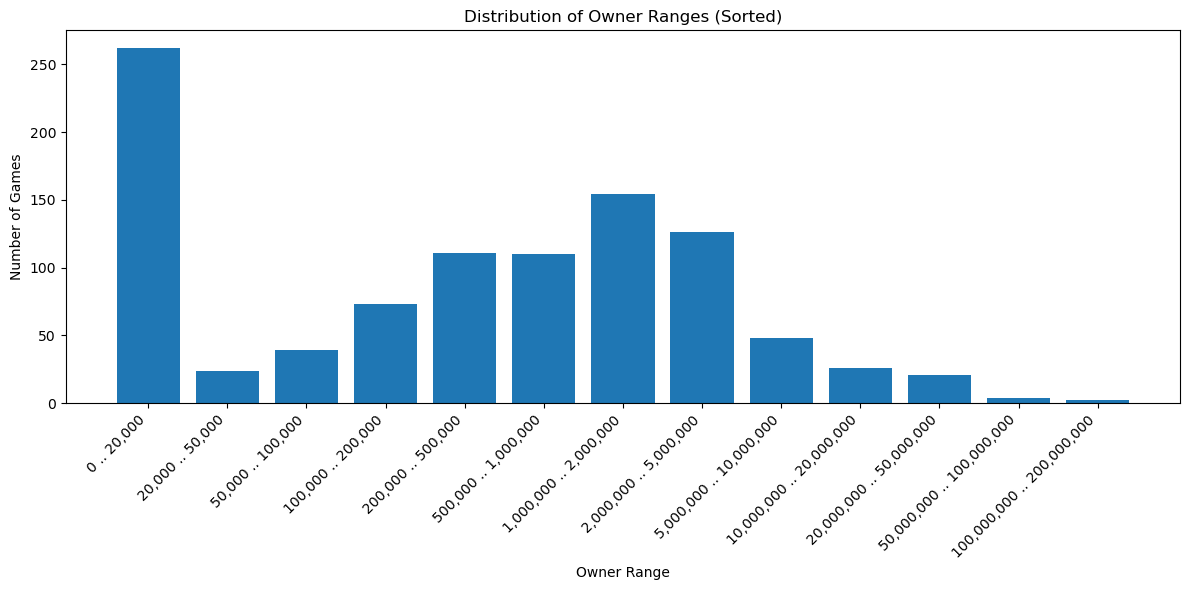

In [341]:
# visualize the distribution with a bar chart
plt.figure(figsize=(12, 6))
plt.bar(sorted_keys, sorted_values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Owner Range')
plt.ylabel('Number of Games')
plt.title('Distribution of Owner Ranges (Sorted)')
plt.tight_layout()
plt.show()

In [342]:
# extract features and construct a DataFrame for modeling
data_list = []

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
            
        game = json.loads(line)
        
        # Safely extract nested structures
        languages = game.get("supported_languages", "")
        price = game.get("price_overview", {})
        platforms = game.get("platforms", {})
        achievements = game.get("achievements", {})
        genres_data = game.get("genres", [])
        
        # Parse language count safely handling empty strings
        lang_list = [lang for lang in languages.split(",") if lang]
        
        row = {
            "appid": game.get("steam_appid"),
            "owners_range": game.get("owners_range", "0 .. 0"),
            
            # Continuous / Integer features
            "lang_count": len(lang_list),
            "cat_count": len(game.get("categories", [])),
            "genre_count": len(genres_data),
            "initial_price": price.get("initial", 0),
            "dlc_count": len(game.get("dlc", [])),
            "achievement_count": achievements.get("total", 0),
            
            # Binary features (0 or 1)
            "has_chinese": 1 if "Simplified Chinese" in languages else 0,
            "has_mac": 1 if platforms.get("mac") else 0,
            "has_controller": 1 if game.get("controller_support") else 0,
            
            # Raw categorical feature
            "genres": [g.get("description") for g in genres_data]
        }
        data_list.append(row)

df = pd.DataFrame(data_list)

# Verify the DataFrame structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   appid              1000 non-null   int64 
 1   owners_range       1000 non-null   object
 2   lang_count         1000 non-null   int64 
 3   cat_count          1000 non-null   int64 
 4   genre_count        1000 non-null   int64 
 5   initial_price      1000 non-null   int64 
 6   dlc_count          1000 non-null   int64 
 7   achievement_count  1000 non-null   int64 
 8   has_chinese        1000 non-null   int64 
 9   has_mac            1000 non-null   int64 
 10  has_controller     1000 non-null   int64 
 11  genres             1000 non-null   object
dtypes: int64(10), object(2)
memory usage: 93.9+ KB
None


In [343]:
# add a new feature: days since release
# Extract release date strings and compute days since release
dates = []

# Extract raw date strings maintaining strict row order
with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        game = json.loads(line)
        # Safely extract the date string; fallback to empty string
        date_str = game.get("release_date", {}).get("date", "")
        dates.append(date_str)

# Parse strings to datetime objects
# errors='coerce' forces unparseable strings (e.g., "Q3 2021") to NaT (Not a Time)
parsed_dates = pd.to_datetime(pd.Series(dates), format='mixed', errors='coerce')

current_time = pd.Timestamp.now()
days_since_release = (current_time - parsed_dates).dt.days

# Impute missing values (NaT -> NaN) using the median to preserve distribution
days_since_release = days_since_release.fillna(days_since_release.median())

# Append the new feature to the existing DataFrame
df['days_since_release'] = days_since_release.astype(int)

In [344]:
# add a new feature: publisher frequency encoding

pub_data = []

# add publisher data to df
with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        game = json.loads(line)
        appid = game.get("steam_appid")
        
        pubs = game.get("publishers", [])
        primary_pub = pubs[0] if isinstance(pubs, list) and len(pubs) > 0 else "Unknown"
        
        pub_data.append({"appid": appid, "publisher": primary_pub})

df_pub = pd.DataFrame(pub_data)
df = df.merge(df_pub, on="appid", how="left")

# Frequency Encoding: compute the frequency of each publisher in the dataset
pub_counts = df['publisher'].value_counts()
df['publisher_scale'] = df['publisher'].map(pub_counts).fillna(1).astype(int)


df = df.drop(columns=['publisher'])

# print the distribution of the new feature
print(df['publisher_scale'].describe())
print("\ntop ：")
print(pub_counts.head())

count    1000.000000
mean        6.676000
std        10.708394
min         1.000000
25%         1.000000
50%         2.000000
75%         8.250000
max        47.000000
Name: publisher_scale, dtype: float64

top ：
publisher
SEGA                47
CAPCOM Co., Ltd.    26
Electronic Arts     20
Square Enix         17
Deep Silver         14
Name: count, dtype: int64


In [345]:
# add a new feature: recommendations
rec_data = []

# extract recommendations data and construct a DataFrame
with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        game = json.loads(line)
        appid = game.get("steam_appid")
        
        recommendations = game.get("recommendations", {}).get("total", 0)
        
        rec_data.append({"appid": appid, "recommendations": recommendations})

df_rec = pd.DataFrame(rec_data)
df = df.merge(df_rec, on="appid", how="left")

df['recommendations'] = df['recommendations'].fillna(0)

In [346]:
# check future releases
future_releases = df[df['days_since_release'] < 0]
print(f"future releases: {len(future_releases)}")

if len(future_releases) > 0:
    print(future_releases[['appid', 'days_since_release']].head())

df = df[df['days_since_release'] >= 0].copy()

df = df.reset_index(drop=True)

print(f"\ntotal number of valid samples: {len(df)}")

future releases: 5
       appid  days_since_release
15   3768760                 -75
95   3787240                -146
500  2814990                 -13
651  4144680                -103
870  3321460                  -6

total number of valid samples: 995


In [347]:
# remove future releases from the dataset
future_releases = df[df['days_since_release'] < 0]
print(f"future releases: {len(future_releases)}")

future releases: 0


days_since_release skewness: 1.4072
recommendations skewness: 17.1253
--------------------------------------------------


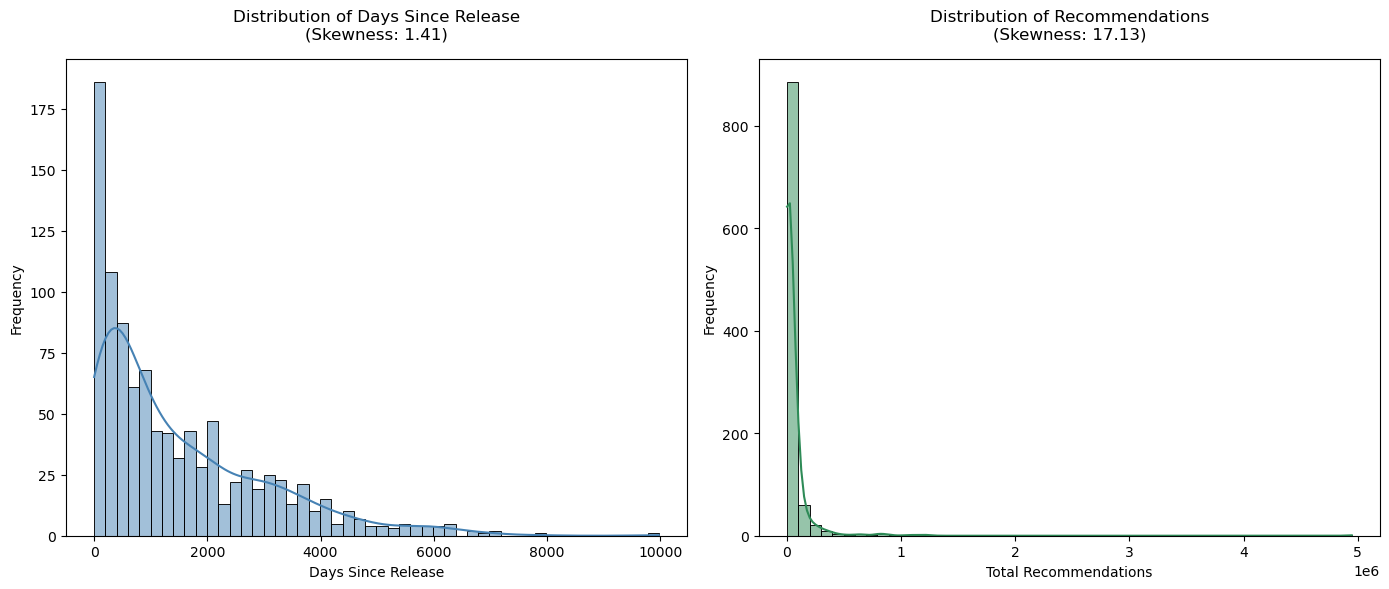

In [348]:
# check skewness of the new feature and visualize its distribution
from scipy.stats import skew

skew_days = df['days_since_release'].skew()
skew_recs = df['recommendations'].skew()

print(f"days_since_release skewness: {skew_days:.4f}")
print(f"recommendations skewness: {skew_recs:.4f}")
print("-" * 50)

# visualize the distributions of days_since_release and recommendations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# days_since_release 
sns.histplot(df['days_since_release'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of Days Since Release\n(Skewness: {skew_days:.2f})', pad=15)
axes[0].set_xlabel('Days Since Release')
axes[0].set_ylabel('Frequency')

# recommendations 
sns.histplot(df['recommendations'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'Distribution of Recommendations\n(Skewness: {skew_recs:.2f})', pad=15)
axes[1].set_xlabel('Total Recommendations')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [349]:
# log transform 'days_since_release'
df['log_days_since_release'] = np.log1p(df['days_since_release'])
df = df.drop(columns=['days_since_release'])

In [350]:
# log transform the recommendations to reduce skewness
df['log_recommendations'] = np.log1p(df['recommendations'])

df = df.drop(columns=['recommendations'])

# print the distribution of the new feature
print("log_recommendations statistics：")
print(df['log_recommendations'].describe())

log_recommendations statistics：
count    995.000000
mean       8.412511
std        3.222019
min        0.000000
25%        7.476431
50%        9.035511
75%       10.453481
max       15.414605
Name: log_recommendations, dtype: float64


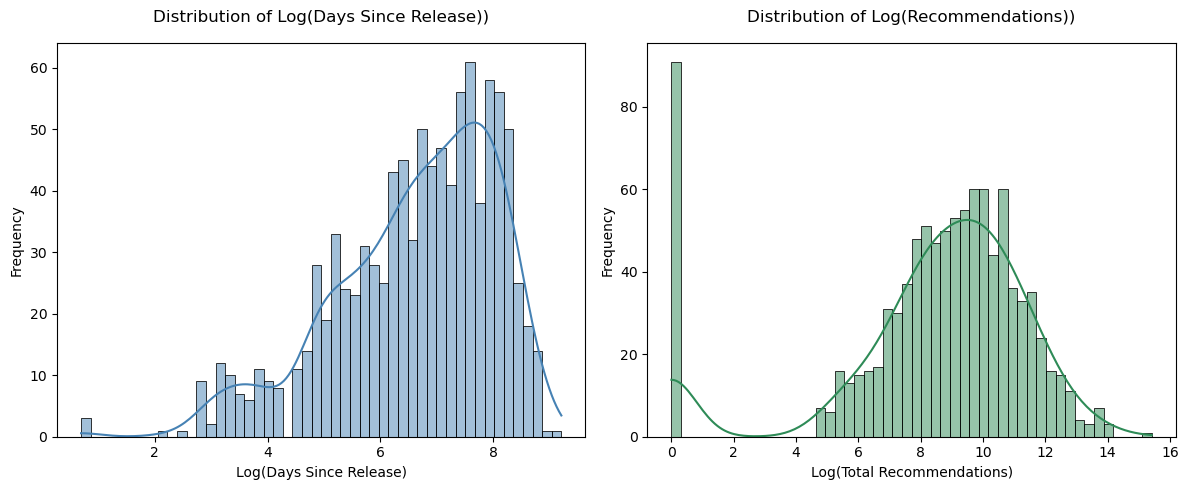

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#log_days_since_release
sns.histplot(df['log_days_since_release'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of Log(Days Since Release))', pad=15)
axes[0].set_xlabel('Log(Days Since Release)')
axes[0].set_ylabel('Frequency')

# log_recommendations
sns.histplot(df['log_recommendations'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'Distribution of Log(Recommendations))', pad=15)
axes[1].set_xlabel('Log(Total Recommendations)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [352]:
df.head()

,appid,owners_range,lang_count,cat_count,genre_count,initial_price,dlc_count,achievement_count,has_chinese,has_mac,has_controller,genres,publisher_scale,log_days_since_release,log_recommendations
0,206420,"5,000,000 .. 10,000,000",8,12,2,1999,0,73,0,0,1,"[Action, Adventure]",14,8.431635,10.956771
1,1888160,"2,000,000 .. 5,000,000",13,14,1,5999,0,30,1,0,0,[Action],4,6.838405,11.075242
2,2076140,"20,000 .. 50,000",5,11,4,1799,8,49,1,1,1,"[Adventure, Casual, Indie, Simulation]",1,6.448889,7.224753
3,312980,"50,000 .. 100,000",2,5,2,3499,30,39,0,0,0,"[Simulation, Strategy]",1,8.205765,6.966024
4,2022670,"200,000 .. 500,000",13,15,1,5999,8,38,1,0,1,[Action],47,6.779922,7.872074


In [353]:
# Unnest the lists in the 'genres' column to individual rows, then compute frequencies
genre_counts = df['genres'].explode().value_counts()

print("genre count：")
print(genre_counts)

# check the total number of unique genres
unique_genre_count = genre_counts.shape[0]
print(f"\ntotal unique genres: {unique_genre_count}")

genre count：
genres
Action                   540
Adventure                416
Indie                    408
Simulation               312
RPG                      296
Strategy                 225
Casual                   192
Early Access             127
Free To Play             106
Massively Multiplayer     73
Sports                    56
Racing                    47
Utilities                  5
Animation & Modeling       4
Design & Illustration      3
Game Development           3
Video Production           3
Audio Production           2
Photo Editing              2
Education                  1
Web Publishing             1
Name: count, dtype: int64

total unique genres: 21


In [354]:
# one-hot encode the 'genres' column
mlb = MultiLabelBinarizer()

genres_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

# filter out genres that appear in less than 48 games
genre_counts = genres_encoded.sum()
top_genres = genre_counts[genre_counts >= 48].index.tolist()

# make final genre features with prefix, and merge back to original DataFrame
genres_final = genres_encoded[top_genres].add_prefix('is_')
df = pd.concat([df.drop(columns=['genres']), genres_final], axis=1)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     995 non-null    int64  
 1   owners_range              995 non-null    object 
 2   lang_count                995 non-null    int64  
 3   cat_count                 995 non-null    int64  
 4   genre_count               995 non-null    int64  
 5   initial_price             995 non-null    int64  
 6   dlc_count                 995 non-null    int64  
 7   achievement_count         995 non-null    int64  
 8   has_chinese               995 non-null    int64  
 9   has_mac                   995 non-null    int64  
 10  has_controller            995 non-null    int64  
 11  publisher_scale           995 non-null    int32  
 12  log_days_since_release    995 non-null    float64
 13  log_recommendations       995 non-null    float64
 14  is_Action 

In [355]:
# get the lower bound of owner range for each row
df['lower_bound'] = df['owners_range'].apply(get_lower_bound)

# rank the lower bounds to create a new integer target variable (owners_level)
df['owners_level'] = df['lower_bound'].rank(method='dense').astype(int)

df = df.drop(columns=['owners_range', 'lower_bound'])


In [356]:
print(df['owners_level'].value_counts().sort_index())

owners_level
1     257
2      24
3      39
4      73
5     111
6     110
7     154
8     126
9      48
10     26
11     21
12      4
13      2
Name: count, dtype: int64


In [357]:
# combine owner levels into 4 classes based on the defined bins, avoid levels with very few samples
bins = [0, 1, 5, 8, float('inf')]
labels = [1, 2, 3, 4]

df['owners_class'] = pd.cut(df['owners_level'], bins=bins, labels=labels).astype(int)
df = df.drop(columns=['owners_level'])



In [358]:
print(df['owners_class'].value_counts().sort_index())

owners_class
1    257
2    247
3    390
4    101
Name: count, dtype: int64


In [359]:
X = df.drop(columns=['appid', 'owners_class'])
y = df['owners_class']

# split dataset to 80% training and 20% testing
# stratefy = y: ensure the proportion of each owners_class is maintained in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 


# train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# model evaluation
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.90      0.87      0.88        52
           2       0.86      0.76      0.80        49
           3       0.80      0.95      0.87        78
           4       1.00      0.65      0.79        20

    accuracy                           0.85       199
   macro avg       0.89      0.80      0.84       199
weighted avg       0.86      0.85      0.85       199



In [360]:
# grid search for hyperparameter tuning of Random Forest
# Define the parameter grid
# Focused on controlling overfitting and handling class imbalance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 12, 15, 17, 20],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}
# n_estimators: number of trees in the forest
# max_depth: maximum depth of each tree (None means no limit)
# min_samples_leaf: minimum number of samples required to be at a leaf node
# class_weight: 'balanced' uses the values of y to automatically adjust weights inversely proportional to class frequencies, 
# while 'balanced_subsample' help with imbalanced datasets.

# Instantiate GridSearchCV
# scoring='f1_macro' forces the search to prioritize performance across all classes equally
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_macro',
    n_jobs=-1
)

# Execute grid search on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

# Evaluate the best model found by grid search
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_optimized))

Best Parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 17, 'min_samples_leaf': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           1       0.90      0.87      0.88        52
           2       0.87      0.80      0.83        49
           3       0.82      0.92      0.87        78
           4       0.81      0.65      0.72        20

    accuracy                           0.85       199
   macro avg       0.85      0.81      0.83       199
weighted avg       0.85      0.85      0.85       199



In [361]:
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)
print("\nTop 10 important features:")
print(feature_importances.sort_values(ascending=False).head(20))


Top 10 important features:
log_recommendations       0.328458
log_days_since_release    0.243832
achievement_count         0.058567
initial_price             0.057102
cat_count                 0.056492
lang_count                0.045143
dlc_count                 0.038096
publisher_scale           0.030304
genre_count               0.022681
is_Free To Play           0.016453
is_Action                 0.013720
is_Adventure              0.009048
has_mac                   0.008997
has_chinese               0.008384
has_controller            0.008216
is_RPG                    0.008177
is_Indie                  0.008147
is_Simulation             0.008094
is_Strategy               0.008037
is_Casual                 0.007409
dtype: float64


In [362]:
train_accuracy = best_rf_model.score(X_train, y_train)
test_accuracy = best_rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.98
Testing Accuracy: 0.85


In [364]:
# XGBoost
param_grid_xgb = {
    # limit tree depth to prevent overfitting
    'max_depth': [2, 4, 6, 8, 10, 12, 14],
    
    # learning rate: step size, has strong negative correlation with n_estimators
    'learning_rate': [0.05, 0.1, 0.2, 0.4, 0.5, 0.6],

}


xgb_base = XGBClassifier(
    n_estimators=200,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

# Instantiate GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5, # 5 fold cross-validation
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1


grid_search_xgb.fit(X_train, y_train_xgb)

# best parameters and evaluation
print("XGBoost Best Parameters:")
print(grid_search_xgb.best_params_)

best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb_opt = best_xgb_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test_xgb + 1, y_pred_xgb_opt + 1))

Fitting 5 folds for each of 42 candidates, totalling 210 fits
XGBoost Best Parameters:
{'learning_rate': 0.2, 'max_depth': 12}

Classification Report:

              precision    recall  f1-score   support

           1       0.89      0.81      0.85        52
           2       0.76      0.80      0.78        49
           3       0.83      0.90      0.86        78
           4       0.82      0.70      0.76        20

    accuracy                           0.83       199
   macro avg       0.83      0.80      0.81       199
weighted avg       0.83      0.83      0.83       199



Top 20 Feature Importance (gain):
log_recommendations         1.645822
log_days_since_release      1.216235
is_Casual                   0.616806
is_Early Access             0.587699
is_Free To Play             0.525891
initial_price               0.373487
cat_count                   0.321118
has_controller              0.279633
is_Indie                    0.267116
is_Simulation               0.267099
genre_count                 0.255861
is_Strategy                 0.247196
publisher_scale             0.242098
dlc_count                   0.211674
has_mac                     0.206766
has_chinese                 0.199042
is_RPG                      0.183231
achievement_count           0.180097
is_Massively Multiplayer    0.170036
is_Sports                   0.160442
dtype: float64


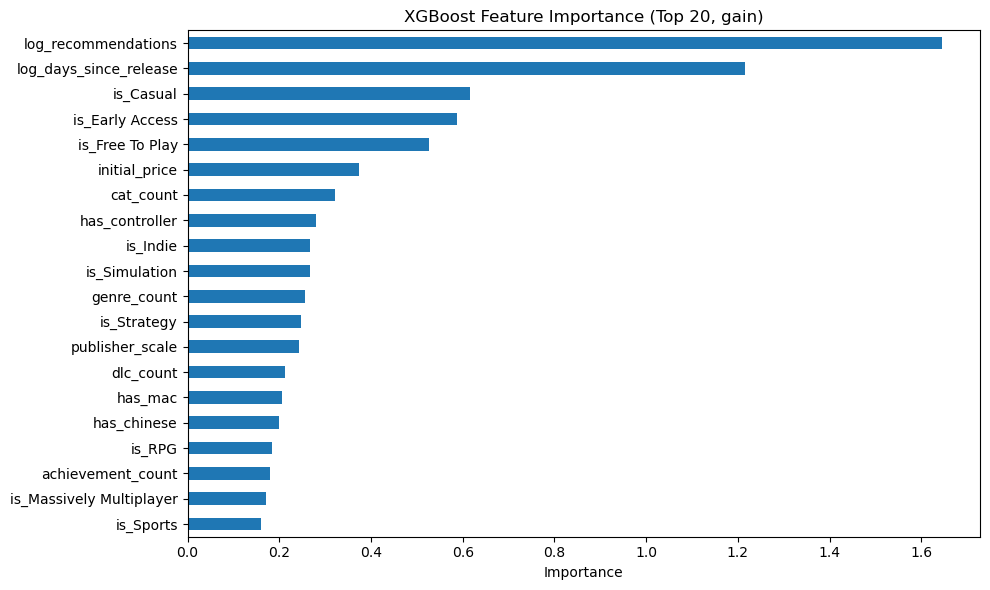

In [378]:
# print the top 20 important features based on gain
importance_gain = pd.Series(
    best_xgb_model.get_booster().get_score(importance_type="gain")
)

fmap = {f"f{i}": col for i, col in enumerate(X.columns)}
importance_gain.index = importance_gain.index.map(lambda k: fmap.get(k, k))
importance_gain = importance_gain.sort_values(ascending=False)

print("Top 20 Feature Importance (gain):")
print(importance_gain.head(20))

# virtualize the top 20 important
plt.figure(figsize=(10, 6))
importance_gain.head(20).sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance (Top 20, gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


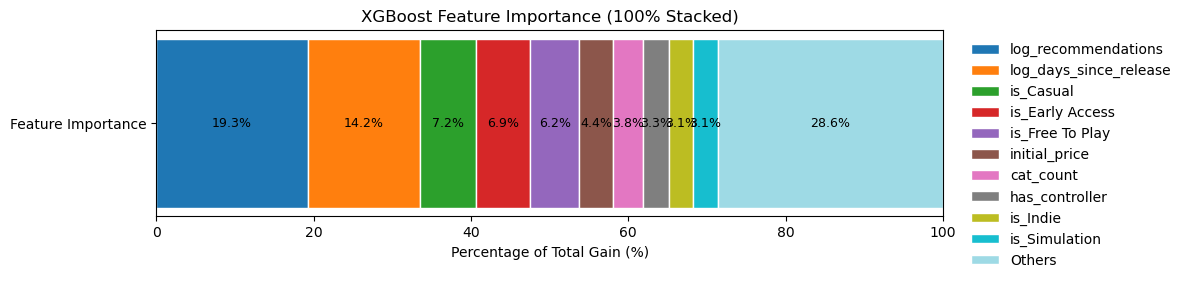

In [ ]:
# stacked bar chart of feature importance 
importance_gain = pd.Series(
    best_xgb_model.get_booster().get_score(importance_type="gain")
)
fmap = {f"f{i}": col for i, col in enumerate(X.columns)}
importance_gain.index = importance_gain.index.map(lambda k: fmap.get(k, k))
importance_gain = importance_gain.sort_values(ascending=False)

importance_pct = importance_gain / importance_gain.sum() * 100

# top 10 features + "Others"
top_n = 10
top_pct = importance_pct.head(top_n).copy()
others_pct = 100 - top_pct.sum()

plot_pct = top_pct.copy()
if others_pct > 0:
    plot_pct["Others"] = others_pct

plt.figure(figsize=(12, 2.8))
left = 0.0
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_pct)))

for (name, val), color in zip(plot_pct.items(), colors):
    plt.barh(y=["Feature Importance"], width=val, left=left, color=color, edgecolor="white", label=name)
    if val >= 3:
        plt.text(left + val / 2, 0, f"{val:.1f}%", ha="center", va="center", fontsize=9, color="black")
    left += val

plt.xlim(0, 100)
plt.xlabel("Percentage of Total Gain (%)")
plt.title("XGBoost Feature Importance (100% Stacked)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

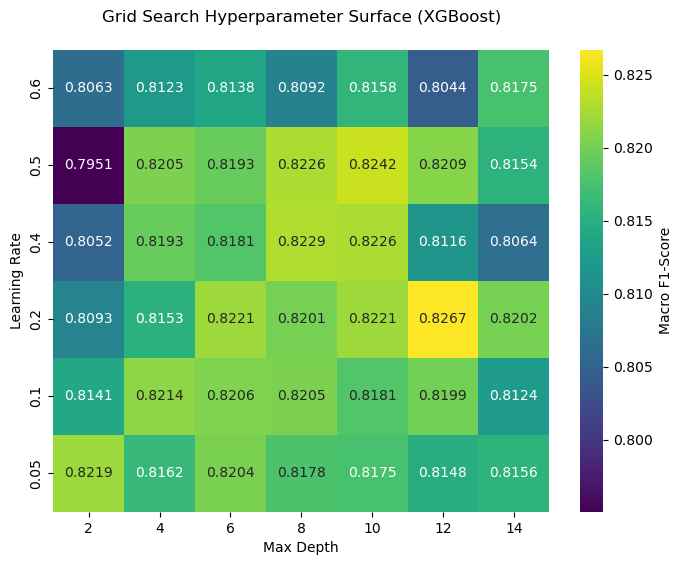

In [366]:
#heat map graphing
cv_results = pd.DataFrame(grid_search_xgb.cv_results_)

scores_df = cv_results[['param_max_depth', 'param_learning_rate', 'mean_test_score']].copy()

scores_df['param_max_depth'] = scores_df['param_max_depth'].astype(int)
scores_df['param_learning_rate'] = scores_df['param_learning_rate'].astype(float)
scores_df['mean_test_score'] = scores_df['mean_test_score'].astype(float)

heatmap_data = scores_df.pivot(
    index='param_learning_rate', 
    columns='param_max_depth', 
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".4f", 
    cmap="viridis",
    cbar_kws={'label': 'Macro F1-Score'}
)

plt.title("Grid Search Hyperparameter Surface (XGBoost)", pad=20)
plt.xlabel("Max Depth")
plt.ylabel("Learning Rate")
plt.gca().invert_yaxis()


In [372]:
xgb_train_accuracy = best_xgb_model.score(X_train, y_train_xgb)
xgb_test_accuracy = best_xgb_model.score(X_test, y_test_xgb)

print(f"XGBoost Training Accuracy: {xgb_train_accuracy:.2f}")
print(f"XGBoost Testing Accuracy: {xgb_test_accuracy:.2f}")

XGBoost Training Accuracy: 1.00
XGBoost Testing Accuracy: 0.83


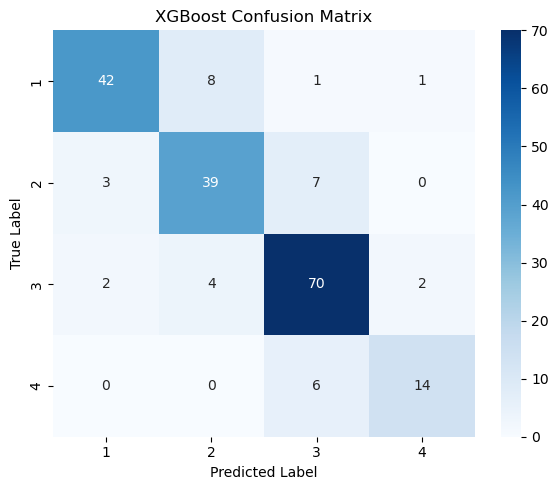

In [ ]:
# confusion matrix
y_true = y_test_xgb + 1
y_pred = y_pred_xgb_opt + 1

cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()